# Statistik.. men i Python
I denne notebook får I øvelsen i at omsætte håndregnins-matematik til Python. <br>
Det er de samme tal, som i jeres statistik grupperegning, så I bør kunne sammenligne resultater direkte, for at se om I har regnet rigtigt.

Helt overordnet bliver I introduceret til hvordan I går fra at skulle skrive matematikken helt ud, til hvordan vi kan få pakker til at gøre det lidt nemmere for os selv. <br>
Vær opmærksom på, at man ikke (nemt) kan skrive enheder i koden, så hold godt øje med hvilke enheder du regner med og sørg for de alle er ens før du begynder at regne!

## Opgave 1 (Middelværdi)

### 1.1
Dine undervisere har gået nogle lange tur, imens de har været i Sisimiut. Den første tur var på Palasip Qaqqaa, som er 551 meter højt. Vandreturen var på 5,2 km. <br>
Den anden tur var på Nasaasaaq, hvor der ligger et godt udsigtsplateau 650 meter oppe. Vandreturen var på 5,8 km. Dagen efter den anden tur på Nasasaaq, var dine undervisere ærgerlige over de ikke nåede toppen, så de tog op igen på Nasaasaaq og gik efter toppen. Toppen er 784 meter høj, og vandreturen var på 6,5 km.

#### 1. Hvor langt har din underviser gået på de tre ture i alt?

In [ ]:
sum = ?
print(sum)

#### 2. Hvad var den gennemsnitlige distance for de tre ture?

In [ ]:
antal = ?
gennemsnit = sum/antal

print(gennemsnit)

#### 3. Hvor højt har udsigstpunkterne været i gennemsnit?

In [ ]:
sum = 0
antal = 0
for værdi in [?,?,?]:
    sum += værdi
    antal += 1

gennemsnit = sum/antal
print(gennemsnit)

### 1.2
Din underviser beder din klasse om at regne en grupperegning. Der er 5 elever i klassen og hver bruger følgende mængde tid til at regne grupperegningen:
- person 1 = 48 min
- person 2 = 1 time og 12 min
- person 3 = 37 min
- person 4 = 1 time og 37 min
- person 5 = 57 min

Hvor lang tid har grupperegningen taget i gennemsnit?

In [ ]:
import numpy as np # <--- importer en pakke for at klare matematikken for os, nu hvor vi kender formlerne

tider = np.array([?, ?, ?, ?, ?]) # omdan til minutter og regn med fælles enhed
gennemsnit = np.mean(tider) * 60 # omdan til sekunder for at kunne regne "resterne"

timer = gennemsnit//60//60
minutter = gennemsnit%60%60
sekunder = gennemsnit%60%60//1

print(f'{timer:1.0f} time, {minutter:1.0f} minutter og {sekunder:1.0f} sekunder')

### 1.3
Din underviser vil gerne vide hvad gennemsnits-positionen af punkterne i koordinatsystemet nedenfor er. <br>
Regn gennemsnitspositionen og indkorporer den i figuren.

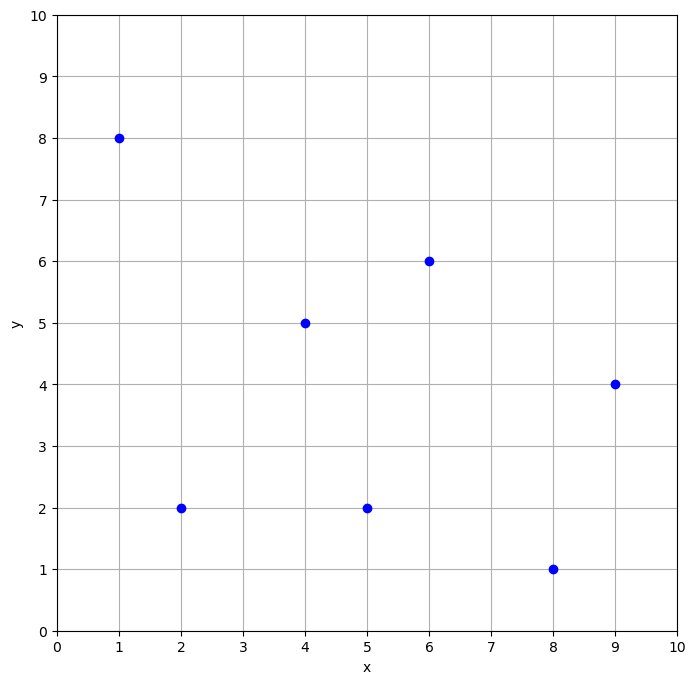

In [ ]:
import matplotlib.pyplot as plt # <--- pakke til at lave figurer

punkter = np.array([
    [?,?,?,?,?,?,?], # x-værdier
    [?,?,?,?,?,?,?], # y-værdier
    ])

gennemsnit_x = np.mean(punkter[0])
gennemsnit_y = np.mean(punkter[1])

plt.figure(figsize=(8,8))
plt.scatter(punkter[0], punkter[1], color='#0000ff', zorder=5)
plt.scatter(gennemsnit_x, gennemsnit_y, color='#ff9500', zorder=4)
plt.grid(True, 'both', zorder=0)
plt.xticks(np.arange(0,11,1))
plt.yticks(np.arange(0,11,1))
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print(f'gennemsnit for x-koordinater: {gennemsnit_x}')
print(f'gennemsnit for y-koordinater: {gennemsnit_y}')

## Opgave 2 (Varians og spredning)

### 2.1
Udregn nu varians for både x- og y-koordinaterne i figuren 

In [ ]:
varians_x = 0
varians_y = 0
for punkt in punkter.T:
    varians_x += (punkt[0]-gennemsnit_x)**2
    varians_y += (punkt[1]-gennemsnit_y)**2

# OBS! Vi bruger (n-1), fordi vi estimerer variansen ud fra stikprøvens eget gennemsnit 
# i stedet for den sande (i dette tilfælde ukendte) middelværdi. Det koster én frihedsgrad 
# og gør at variansen ikke bliver systematisk for lille (bias).
varians_x /= (np.shape(punkter)[1] - 1) 
varians_y /= (np.shape(punkter)[1] - 1) 

print(varians_x)
print(varians_y)

### 2.2 

Udregn nu spredning for både x- og y-koordinaterne i figuren

In [ ]:
# en lidt nemmere måde at regne varians på:
varians_x = np.var(punkter[0], ddof=1) # OBS: ddof=1 er "Delta Degree of Freedom", og i denne formel er det defineret ved (n-ddof), så derfor sætter vi ddof=1
varians_y = np.var(punkter[1], ddof=1) # igen: se kommentar ovenfor

spredning_x = np.sqrt(varians_x)
spredning_y = np.sqrt(varians_y)

print(spredning_x)
print(spredning_y)

### 2.3
Ud fra sidste opgave ved vi at der er en spredning på koordinaterne. Antaget at det er usikkerheden, hvad vil den samlede usikkerhed på positionsløsningen være? <br>
Hint: se fejlpropagering i slides

In [ ]:
# en anden måde at regne spredning på
spredning_x = np.std(punkter[0], ddof=1)
spredning_y = np.std(punkter[1], ddof=1)

fejl = np.sqrt(spredning_x**2 + spredning_y**2) # fejlpropageringsloven
print(fejl)